# Ejemplo de regresión lineal

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de la creación de un modelo predictivo para una variable continua.

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_regresion/data_casas.csv

--2026-04-16 01:17:49--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_regresion/data_casas.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7417 (7.2K) [text/plain]
Saving to: ‘data_casas.csv’

data_casas.csv      100%[===================>]   7.24K  --.-KB/s    in 0s      

2026-04-16 01:17:49 (67.6 MB/s) - ‘data_casas.csv’ saved [7417/7417]



In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
data = pd.read_csv('data_casas.csv')
data.head()

,metros_cuadrados,habitaciones,edad,barrio,precio
0,71.650357,5,18,centro,107775.0
1,94.120642,5,7,sur,114052.0
2,118.319694,1,29,centro,126872.0
3,37.164890,2,17,sur,32465.0
4,94.381138,5,23,centro,129039.0


## Objetivo

Predecir el precio de la vivienda, considerando `algunas` de sus características

# Fase 2 - Entendimiento de los datos

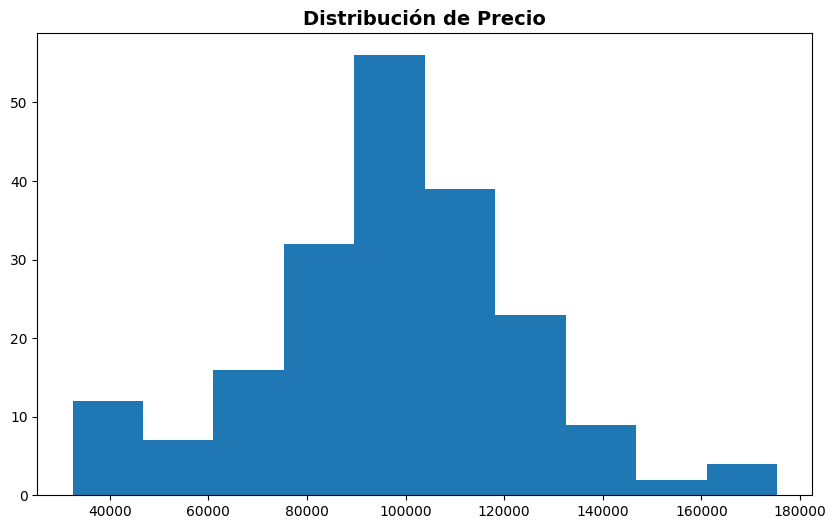

In [4]:
data.precio.hist(bins=10, figsize=(10,6), grid=False)
plt.title("Distribución de Precio", fontsize=14, fontweight="bold")
plt.show()

## Detección de inconsistencias

In [5]:
# Detectar inconsistencias
inconsistentes = data[(data["metros_cuadrados"] <= 0) | (data["precio"] <= 0) | (data["edad"] < 0) | (data["habitaciones"] <= 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,metros_cuadrados,habitaciones,edad,barrio,precio


In [6]:
data.barrio.unique()

array(['centro', 'sur', 'norte'], dtype=object)

## Detección de nulos

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   metros_cuadrados  200 non-null    float64
 1   habitaciones      200 non-null    int64  
 2   edad              200 non-null    int64  
 3   barrio            200 non-null    object 
 4   precio            200 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB


## Detección de valores atípicos

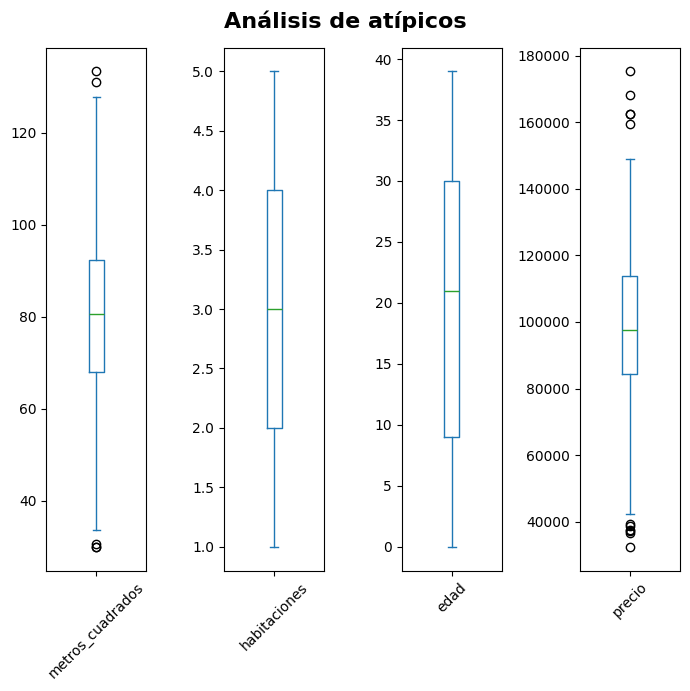

In [8]:
revision_atipicos = ['metros_cuadrados', 'habitaciones', 'edad',	'precio']
fig, axes = plt.subplots(1, 4, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Detección de duplicados

In [9]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

In [10]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)]

,metros_cuadrados,habitaciones,edad,barrio,precio


# Fase 3 - Preparación de datos

**✅ Automatización de fases 3 y 4**

Las fases de preparación y modelamiento se van a automatizar a través del uso de un ´pipeline´.

Ventajas de usar esta técnica:

+ Se puede encadenar imputación de nulos, codificación de variables categóricas y el modelo.

+ Permite hacer el mismo preprocesamiento en train y test sin errores.

+ Se vuelve reutilizable para producción o para predecir sobre nuevos datos.

Posible desventaja:

+ Todo queda encapsulado y no se ve fácilmente cómo quedaron los datos después de cada transformación.

In [11]:
target = "precio"

In [12]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [13]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [14]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [15]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
  """
  Ingeniería de características

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  Returns
  -------
  DataFrame
    Conjunto de datos con nuevas características.
  """
  def __init__(self):
    pass

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    X["metros_por_habitacion"] = X["metros_cuadrados"] / X["habitaciones"]
    return X

In [16]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

In [17]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

## Evaluación de las mejores variables `predictoras`

In [18]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,precio
precio,1.000000
metros_cuadrados,0.763917
habitaciones,0.190496
edad,-0.148565


In [19]:
data.groupby("barrio")[target].mean().sort_values()

,precio
barrio,
sur,82073.750000
norte,96542.229508
centro,111927.880000


In [20]:
encoder = OneHotEncoder(sparse_output=False)
barrio_encoded = encoder.fit_transform(data[["barrio"]])

data_ohe = pd.DataFrame(barrio_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)

data_corr.corr(numeric_only=True)[target]

,precio
metros_cuadrados,0.763917
habitaciones,0.190496
edad,-0.148565
precio,1.000000
barrio_centro,0.417481
barrio_norte,-0.028564
barrio_sur,-0.405082


In [21]:
# Agrega las nuevas columnas para analizar su correlación con la variable objetivo
data_corr = FeatureEngineering().fit_transform(data_corr)
data_corr.corr(numeric_only=True)[target]

,precio
metros_cuadrados,0.763917
habitaciones,0.190496
edad,-0.148565
precio,1.000000
barrio_centro,0.417481
barrio_norte,-0.028564
barrio_sur,-0.405082
metros_por_habitacion,0.116380


**Importante**

De la tabla anterior se obtienen las mejores `variables predictoras` para el modelo.

# Fase 4 - Modelamiento

In [22]:
# Variables
features_num = ["metros_cuadrados", "habitaciones", "edad"]
features_cat = ["barrio"]
target = "precio"

X = data[features_num + features_cat]
y = data[target]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [24]:
# Crea el pipeline final (preprocesamiento + modelo)
modelo = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("feature_engineering", FeatureEngineering()),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Entrenamiento
modelo.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7bfb50bf1760>,
                                     kw_args={'drop': False})),
                ('feature_engineering', FeatureEngineering()),
                ('preprocesador',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()...
                                                                                  Pipeline(steps=[('winsorizer',
                                                                                                   Winsorizer()),
                                                                                                  ('imputer',
                                                                                                   SimpleImputer()),
                                                                                                  ('escalado',
                                                                                                   StandardScaler())]),
                                                                                  ['metros_cuadrados',
                                                                                   'habitaciones',
                                                                                   'edad']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore'))]),
                                                                                  ['barrio'])]))),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [25]:
# Predicciones
y_pred = modelo.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")

print(f"{'R2':<6}: {r2:.3f}")
print(f"{'MAE':<6}: {mae:,.0f}")


--- Métricas del modelo ---
R2    : 0.741
MAE   : 10,129


In [26]:
y_pred.round(2)

array([104775.68,  88219.2 ,  87778.01,  88513.48, 104784.01, 108681.26,
       130627.51, 102777.04, 103559.42,  82784.45,  73312.97, 119259.  ,
        99206.47, 118684.  ,  67878.78,  82044.6 , 100731.28,  68246.58,
       103876.77,  98498.46, 109495.01,  95621.36,  79835.4 , 105964.74,
        90574.69,  58852.89,  71666.22, 101516.97, 113227.67,  95287.82,
        80733.64,  73148.6 ,  95877.96,  58305.31, 122607.77,  57838.07,
        82630.32, 104475.36, 126002.32, 113140.49])

In [27]:
# Variables que fueron eliminadas por presentar colinealidad
modelo.named_steps["colinealidad"].columns_to_drop_

[]

In [28]:
# Variables con las cuales fue entrenado el modelo
modelo.named_steps["conversion"].feature_names_

array(['num__metros_cuadrados', 'num__habitaciones', 'num__edad',
       'cat__barrio_norte', 'cat__barrio_sur',
       'remainder__metros_por_habitacion'], dtype=object)

In [29]:
# Predicción del precio de una casa (con datos COMPLETAMENTE nuevos)
nuevo = pd.DataFrame([
    {
        "metros_cuadrados": 90,
        "habitaciones": 3,
        "edad": 12,
        "barrio": "norte"
    }
])

pred = modelo.predict(nuevo)
pred.round(2)

array([111004.4])

In [30]:
# Predicción con datos totalmente nuevos
X_data = pd.DataFrame({
    "metros_cuadrados": [100, 150, 200],
    "habitaciones": [2, 3, 4],
    "edad": [10, 15, 20],
    "barrio": ["centro", "sur", "norte"]
})
prediccion = modelo.predict(X_data)
prediccion.round(2)

array([138039.05, 158708.74, 226139.58])

In [31]:
X_data = pd.DataFrame({
    "metros_cuadrados": [150, 150, 200],
    "habitaciones": [3, 3, 4],
    "edad": [15, 15, 20],
    "barrio": ["centro", "sur", "norte"]
})
prediccion = modelo.predict(X_data)
prediccion.round(2)

array([188983.62, 158708.74, 226139.58])